In [432]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [433]:
data = {
    0.6: [7.7,15.3,23,32,41.8],
    1.0: [9.4,17.4,27.6,37.7,44.4],
    1.4: [11.4,22.5,33.3,44.1,55.6]
}

In [434]:
Ls = [0.93,0.95,1.29]
n = np.arange(1,6)

# **Parte 1**

$f_n = \frac{nv}{2L} \rightarrow v = \frac{2f_nL}{n} = 2 * L * pendiente$

In [435]:
v_ec= lambda pendiente,L: 2*L*pendiente
v_sq = []
pendientes = []
errores_pendientes = []

# *T=0.6N*

In [436]:
L = 0.93
f = data[0.6]
f

[7.7, 15.3, 23, 32, 41.8]

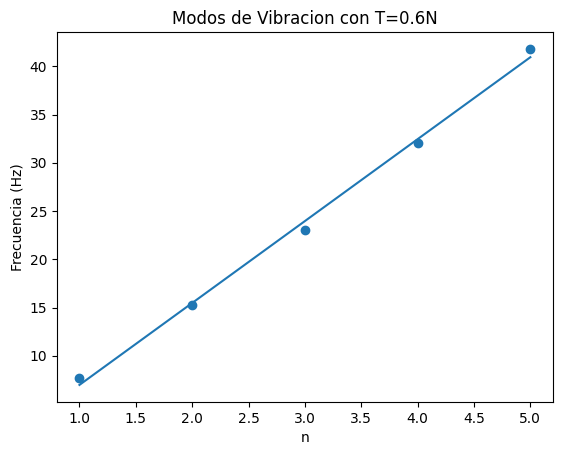

In [437]:
m,c,r_sq,p_val,err_pendiente = linregress(n,f)

plt.scatter(n,f, label="datos")
plt.plot(n,m*n +c, label="fit")
plt.title("Modos de Vibracion con T=0.6N")
plt.xlabel("n")
plt.ylabel("Frecuencia (Hz)")
plt.show()

In [438]:
v = v_ec(m,L)
v_sq.append(v**2)
pendientes.append(m)
errores_pendientes.append(err_pendiente)
print(f"Pendiente = {m}Hz")
print(f"v = {v:.3f}m/s")

Pendiente = 8.49Hz
v = 15.791m/s


# *T=1.0N*

In [439]:
L = 0.95
f = data[1.0]
f

[9.4, 17.4, 27.6, 37.7, 44.4]

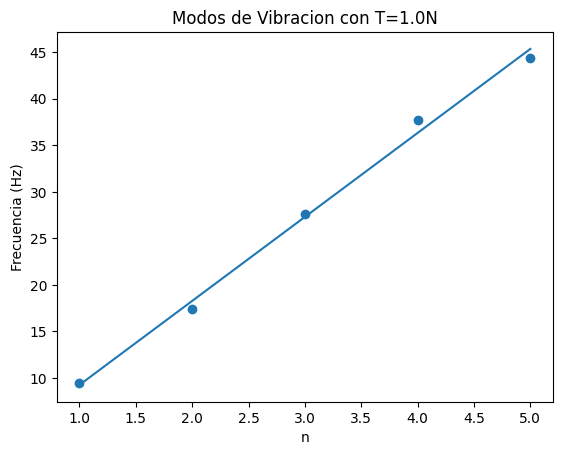

In [440]:
m,c,r_sq,p_val,err_pendiente = linregress(n,f)

plt.scatter(n,f, label="datos")
plt.plot(n,m*n +c, label="fit")
plt.title("Modos de Vibracion con T=1.0N")
plt.xlabel("n")
plt.ylabel("Frecuencia (Hz)")
plt.show()

In [441]:
v = v_ec(m,L)
v_sq.append(v**2)
pendientes.append(m)
errores_pendientes.append(err_pendiente)
print(f"Pendiente = {m}Hz")
print(f"v = {v:.3f}m/s")

Pendiente = 9.030000000000001Hz
v = 17.157m/s


# *T=1.4N*

In [442]:
L = 1.29
f = data[1.4]
f

[11.4, 22.5, 33.3, 44.1, 55.6]

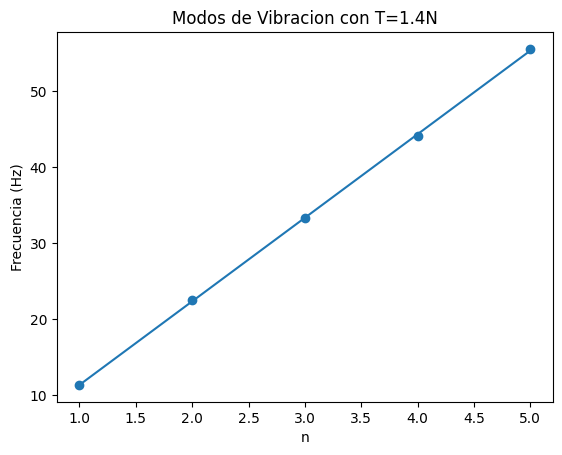

In [443]:
m,c,r_sq,p_val,err_pendiente = linregress(n,f)

plt.scatter(n,f, label="datos")
plt.plot(n,m*n +c, label="fit")
plt.title("Modos de Vibracion con T=1.4N")
plt.xlabel("n")
plt.ylabel("Frecuencia (Hz)")
plt.show()

In [444]:
v = v_ec(m,L)
v_sq.append(v**2)
pendientes.append(m)
errores_pendientes.append(err_pendiente)
print(f"Pendiente = {m}Hz")
print(f"v = {v:.3f}m/s")

Pendiente = 11.000000000000002Hz
v = 28.380m/s


# **Parte 2**

In [445]:
T = np.array([k for k in data.keys()])

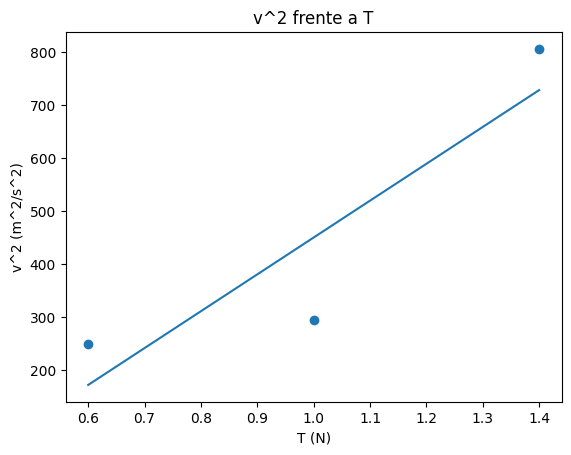

In [446]:
m,c,r_sq,p_val,err_pendiente = linregress(T,v_sq)

plt.scatter(T,v_sq, label="datos")
plt.plot(T,m*T +c, label="fit")
plt.title("v^2 frente a T")
plt.xlabel("T (N)")
plt.ylabel("v^2 (m^2/s^2)")
plt.show()

In [447]:
mu = 1/m
print(f"μ = {mu*1000} g/m")

μ = 1.4387037928085036 g/m


# **Parte 4**

In [448]:
err_f = 0.1 #Hz
err_L = 0.005 # m

## *Incertidumbres para v*

In [449]:
T_vals = [k for k in data.keys()]
for i in range(len(Ls)):
    L = Ls[i]
    T = T_vals[i]
    m_val = pendientes[i]
    err_m = errores_pendientes[i]
    v = np.sqrt(v_sq[i])

    err_v = v*np.sqrt((err_L/L)**2 + (err_m/m_val)**2)
    print(f"T={T}N --> v={v:.3f} ± {err_v:.4f}m/s --> Error Relativo: {(err_v/v)*100}%")

T=0.6N --> v=15.791 ± 0.5341m/s --> Error Relativo: 3.382112332191141%
T=1.0N --> v=17.157 ± 0.6707m/s --> Error Relativo: 3.9094490950603014%
T=1.4N --> v=28.380 ± 0.2120m/s --> Error Relativo: 0.7469570636330094%


## _Incertidumbre para μ_

$\delta \mu = \frac{\delta m}{m^2}$

In [455]:
err_mu = err_pendiente / m**2
print(f"μ = {mu*1000} ± {err_mu*1000} g/m")

μ = 1.4387037928085036 ± 0.6962110372045099 g/m
